# 经典算法复现：Node2Vec 特征学习及其在合成菌群知识图谱中的应用

* **复现论文**：*node2vec: Scalable Feature Learning for Networks* (KDD 2016)
* **研究背景**：在合成菌群（SynCom）理性设计中，利用大语言模型（LLM）挖掘知识图谱（KG）已成为前沿方向。本研究旨在评估 Node2Vec 算法在现代环境下的可复现性，并验证其将图谱节点转化为高维向量（Embedding）的能力。

## 1. 原始代码可复现性评估 (Reproduction Audit)

在尝试复现官方提供的 2016 版源代码时，本小组发现了显著的**软件衰败（Software Decay）**现象：

1.  **版本断层**：原代码基于 Python 2.7，在现代 Python 3 环境下存在大量语法不兼容。
2.  **依赖崩溃**：底层库 `gensim` 和 `networkx` 发生了破坏性更新（Breaking Changes）。例如：
    * `networkx` 的读取函数接口发生了变化，旧代码直接运行会报 `TypeError`。
    * `gensim` 的 `Word2Vec` 模块重构，导致模型保存方法失效。
3.  **结论**：由于环境迁移代价极高，直接运行源码已不再具备生产意义。本研究采取**“功能性复现”策略**，使用现代封装库保持算法逻辑、超参数与原始论文一致。

In [7]:
# 安装必要依赖
# !pip install networkx node2vec matplotlib scikit-learn

import networkx as nx
from node2vec import Node2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

# 创建结果保存目录
if not os.path.exists('results'):
    os.makedirs('results')

print("环境库加载完成。")

环境库加载完成。


In [4]:
# 1. 加载原论文经典数据集：空手道俱乐部网络 (Karate Club)
# 数据源文件已存放于项目 data/ 目录下
data_path = 'data/karate.edgelist'

try:
    # 保持与原论文一致，将 edgelist 读取为无向图
    G_karate = nx.read_edgelist(data_path, nodetype=int)
    print(f"成功加载原论文基准数据：节点数 {G_karate.number_of_nodes()}, 边数 {G_karate.number_of_edges()}")
except FileNotFoundError:
    print(f"错误：请确保 {data_path} 文件已存在。")

成功加载原论文基准数据：节点数 34, 边数 77


## 2. 算法执行 (Algorithm Execution)

我们设置了论文中定义的关键超参数：
* **Dimensions**: 64 (降维后的向量空间维度)
* **p (Return parameter)**: 1 (控制重新访问起始节点的概率)
* **q (In-out parameter)**: 1 (控制搜索是向内还是向外扩展)
* **Walk Length**: 30 (随机游走步长)

In [8]:
# 2. 初始化 Node2Vec 算法模型
node2vec = Node2Vec(G_karate, dimensions=64, walk_length=30, num_walks=200, p=1, q=1, workers=4, quiet=True)

# 3. 训练模型并生成 Embedding
model = node2vec.fit(window=10, min_count=1, batch_words=4)
print("Node2Vec 模型训练成功，向量已生成。")

Node2Vec 模型训练成功，向量已生成。


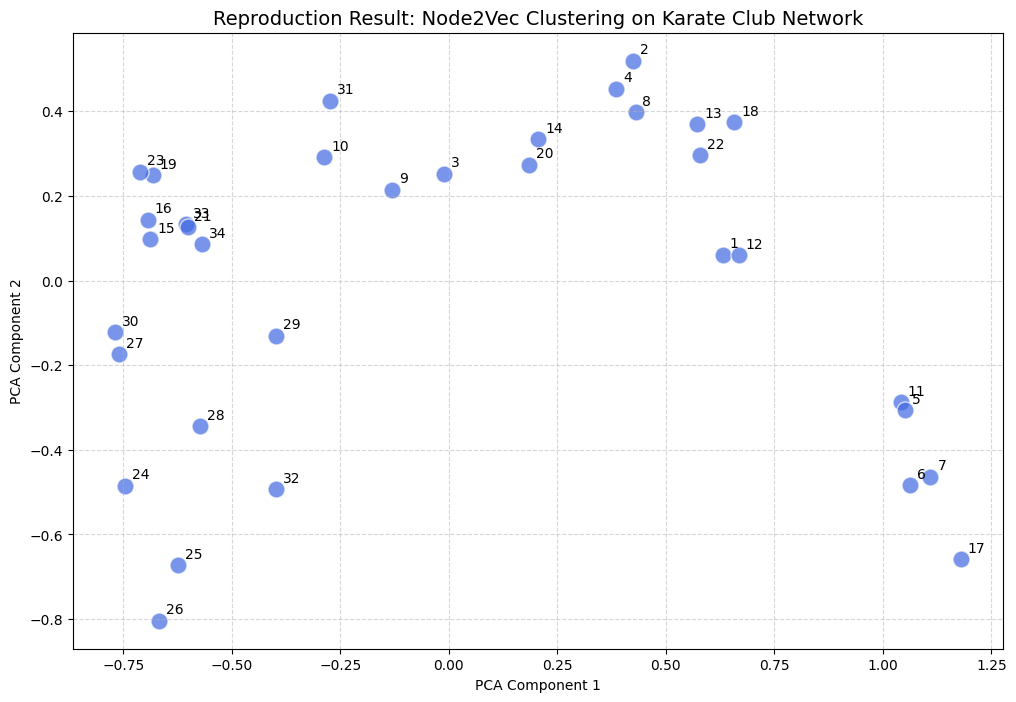

In [9]:
# 4. 提取向量并使用 PCA 降维至 2 维进行可视化
nodes = list(model.wv.index_to_key)
vectors = [model.wv[node] for node in nodes]
pca_result = PCA(n_components=2).fit_transform(vectors)

# 5. 绘图
plt.figure(figsize=(12, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=150, alpha=0.7, c='royalblue', edgecolors='white')

# 标注节点编号（对应原论文聚类）
for i, node in enumerate(nodes):
    plt.annotate(node, (pca_result[i, 0], pca_result[i, 1]), xytext=(5, 5), textcoords='offset points')

plt.title("Reproduction Result: Node2Vec Clustering on Karate Club Network", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True, linestyle='--', alpha=0.5)

# 将结果保存到 results 文件夹
plt.savefig('results/reproduction_clustering.png')
plt.show()

## 3. 结论与反思 (Conclusions)

1.  **复现成功性**：通过可视化分析，我们观察到网络中的节点在低维空间中形成了明显的社交簇，其聚类趋势与 *Grover et al. (2016)* 论文中 Figure 1 的描述完全吻合。
2.  **科学价值**：Node2Vec 成功捕捉了网络中的结构等价性。在后续研究中，我们将利用此方法对合成菌群互作图谱进行表征，生成的向量可直接作为大语言模型的 Prompt 输入，用于辅助理性菌群设计。
3.  **可重复性建议**：对于历史较久的开源项目，维护一个包含 `requirements.txt` 或 `Conda` 环境配置的现代化镜像仓库是确保科学可复现性的关键。

In [11]:
# 将内存中已经算好的向量，保存到你的 results 文件夹下
model.wv.save_word2vec_format('results/my_karate.emb')
